![Google Play Store App Analysis](https://upload.wikimedia.org/wikipedia/commons/7/7f/Google_Play_logo.png)

# Google Play Store App Analysis
- This notebook examines the Google Play Store dataset to identify the most popular app categories, rating trends, pricing dynamics, and data quality issues.
- The objective is to support product and marketing stakeholders with evidence-based insights on category performance, user ratings, and monetization patterns.

## Business Understanding
- Stakeholders: mobile product managers and app marketers.
- Goal: understand which app categories attract the most users, which category ratings are strongest, and how pricing relates to installs.
- Key questions:
  1. Which categories have the most apps and highest user engagement?
  2. Are free apps dominating installs compared to paid apps?

## Data Understanding
- Source dataset: `google_play_store_dataset.csv` with 10,841 app records and 13 attributes.
- Important fields: `App`, `Category`, `Rating`, `Reviews`, `Size`, `Installs`, `Type`, `Price`, `Content Rating`, `Genres`, `Last Updated`, `Current Ver`, `Android Ver`.
- Cleaning priorities:
  - Convert `Price`, `Installs`, `Reviews`, and `Size` to numeric values.
  - Standardize `Type` and handle missing values.
  - Detect duplicate rows and inconsistent formatting.


In [1]:
# Imports and dataset load
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set(style='whitegrid', palette='muted')
    plotting_enabled = True
except ImportError as e:
    plt = None
    sns = None
    plotting_enabled = False
    print(f'Plotting libraries unavailable: {e}. Charts will be skipped.')

# Initialize Spark session
spark = SparkSession.builder.appName('GooglePlayStoreAnalysis').getOrCreate()

# Load dataset using PySpark
file_path = 'google_play_store_dataset.csv'
spark_df = spark.read.csv(file_path, header=True, inferSchema=True)

# Convert to pandas for analysis
df = spark_df.toPandas()

# Display the first rows and basic metadata
print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nPreview of dataset:')
print(df.head(5).to_string(index=False))
print('\nMissing values by column:')
print(df.isnull().sum())

Dataset shape: (10841, 13)

Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Preview of dataset:
                                               App       Category Rating Reviews Size    Installs Type Price Content Rating                    Genres     Last Updated        Current Ver  Android Ver
    Photo Editor & Candy Camera & Grid & ScrapBook ART_AND_DESIGN    4.1     159  19M     10,000+ Free     0       Everyone              Art & Design  January 7, 2018              1.0.0 4.0.3 and up
                               Coloring book moana ART_AND_DESIGN    3.9     967  14M    500,000+ Free     0       Everyone Art & Design;Pretend Play January 15, 2018              2.0.0 4.0.3 and up
U Launcher Lite – FREE Live Cool Themes, Hide Apps ART_AND_DESIGN    4.7   87510 8.7M  5,000,000+ Free     0       Everyone              Art & Design   August 1, 2018              1.2.4 4.0.3 a

Top 10 categories by app count:
Category
FAMILY             1972
GAME               1144
TOOLS               843
MEDICAL             463
BUSINESS            460
PRODUCTIVITY        424
PERSONALIZATION     392
COMMUNICATION       387
SPORTS              384
LIFESTYLE           382

Free vs Paid breakdown:
Type
Free    10039
Paid      800
NaN         1

Top 10 apps by installs:
                                     App      Category Type  Price     Installs  Rating
                          Subway Surfers          GAME Free    0.0 1000000000.0     4.5
                                Facebook        SOCIAL Free    0.0 1000000000.0     4.1
Messenger – Text and Video Chat for Free COMMUNICATION Free    0.0 1000000000.0     4.0
                            Google Drive  PRODUCTIVITY Free    0.0 1000000000.0     4.4
                            Google Drive  PRODUCTIVITY Free    0.0 1000000000.0     4.4
                           Google Photos   PHOTOGRAPHY Free    0.0 1000000000.0     4.5
     

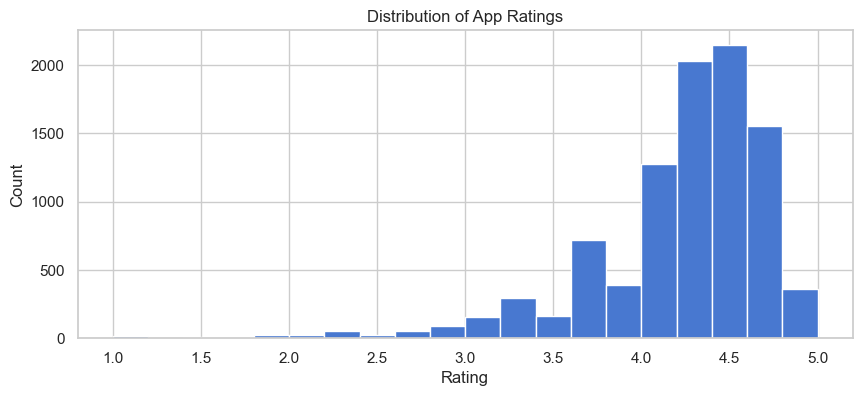

In [20]:
# Exploratory data analysis
# Convert fields for analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset if not already loaded
try:
    df
except NameError:
    df = pd.read_csv('google_play_store_dataset.csv')

# Helper function to clean app size
def parse_size(value):
    if pd.isna(value):
        return np.nan
    
    text = str(value).strip()
    
    if text == 'Varies with device' or text == '':
        return np.nan
    
    if text.endswith('M'):
        return float(text[:-1]) * 1024
    
    if text.endswith('k'):
        return float(text[:-1])
    
    return pd.to_numeric(text, errors='coerce')

# Create copy for EDA
df_eda = df.copy()

# Clean Price
df_eda['Price'] = (
    df_eda['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .replace('Free', '0')
)

df_eda['Price'] = pd.to_numeric(df_eda['Price'], errors='coerce').fillna(0)

# Clean Installs
df_eda['Installs'] = pd.to_numeric(
    df_eda['Installs'].astype(str).str.replace('[+,]', '', regex=True),
    errors='coerce'
)

# Clean Reviews
df_eda['Reviews'] = pd.to_numeric(
    df_eda['Reviews'].astype(str).str.replace(',', '', regex=True),
    errors='coerce'
)

# Clean Rating
df_eda['Rating'] = pd.to_numeric(df_eda['Rating'], errors='coerce')

# Remove invalid ratings
df_eda = df_eda[(df_eda['Rating'].isna()) | ((df_eda['Rating'] >= 1) & (df_eda['Rating'] <= 5))]

# Clean app size
df_eda['Size_kb'] = df_eda['Size'].apply(parse_size)

# Clean Type column
df_eda['Type'] = df_eda['Type'].replace('0', np.nan)

# Display summaries
print('Top 10 categories by app count:')
print(df_eda['Category'].value_counts().head(10).to_string())

print('\nFree vs Paid breakdown:')
print(df_eda['Type'].value_counts(dropna=False).to_string())

print('\nTop 10 apps by installs:')
print(
    df_eda.sort_values('Installs', ascending=False)
    .head(10)[['App', 'Category', 'Type', 'Price', 'Installs', 'Rating']]
    .to_string(index=False)
)

print('\nRating value counts:')
print(df_eda['Rating'].value_counts().sort_index())

# Plot rating distribution using matplotlib
plt.figure(figsize=(10, 4))
plt.hist(df_eda['Rating'].dropna(), bins=20)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

## Data Preparation


In [22]:
# Data preparation and cleaning

df_clean = df.copy()

def parse_price(value):
    if pd.isna(value):
        return 0.0
    text = str(value).strip()
    if text in ('', 'Free', '0', '0.0', 'Everyone'):
        return 0.0
    try:
        return float(text.replace('$', '').replace(',', ''))
    except ValueError:
        return 0.0


def parse_size(value):
    if pd.isna(value) or value == 'Varies with device':
        return np.nan
    text = str(value).strip()
    if text.endswith('M'):
        return float(text[:-1]) * 1024
    if text.endswith('k'):
        return float(text[:-1])
    return pd.to_numeric(text, errors='coerce')


df_clean['Price'] = df_clean['Price'].apply(parse_price)
df_clean['Installs'] = pd.to_numeric(df_clean['Installs'].str.replace('[+,]', '', regex=True), errors='coerce')
df_clean['Reviews'] = pd.to_numeric(df_clean['Reviews'].str.replace(',', '', regex=True), errors='coerce')
df_clean['Size_kb'] = df_clean['Size'].apply(parse_size)

df_clean['Type'] = df_clean['Type'].fillna('Free')

df_clean['IsPaid'] = df_clean['Type'] == 'Paid'

df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')

df_clean = df_clean.drop_duplicates(subset=['App', 'Category', 'Reviews', 'Installs'])

print('Cleaned dataset shape:', df_clean.shape)
print('Missing values after cleaning:')
print(df_clean[['Rating','Reviews','Installs','Size_kb','Type','Price']].isnull().sum())
print('\nSample cleaned data:')
print(df_clean.head(5).to_string(index=False))

Cleaned dataset shape: (10356, 15)
Missing values after cleaning:
Rating      1465
Reviews        1
Installs       1
Size_kb     1527
Type           0
Price          0
dtype: int64

Sample cleaned data:
                                               App       Category  Rating  Reviews Size   Installs Type  Price Content Rating                    Genres     Last Updated        Current Ver  Android Ver  Size_kb  IsPaid
    Photo Editor & Candy Camera & Grid & ScrapBook ART_AND_DESIGN     4.1    159.0  19M    10000.0 Free    0.0       Everyone              Art & Design  January 7, 2018              1.0.0 4.0.3 and up  19456.0   False
                               Coloring book moana ART_AND_DESIGN     3.9    967.0  14M   500000.0 Free    0.0       Everyone Art & Design;Pretend Play January 15, 2018              2.0.0 4.0.3 and up  14336.0   False
U Launcher Lite – FREE Live Cool Themes, Hide Apps ART_AND_DESIGN     4.7  87510.0 8.7M  5000000.0 Free    0.0       Everyone              Art 

In [23]:
# Save cleaned dataset for Tableau or further analysis
cleaned_path = 'google_play_store_dataset_cleaned.csv'
df_clean.to_csv(cleaned_path, index=False)
print(f'Cleaned dataset saved to {cleaned_path}')

Cleaned dataset saved to google_play_store_dataset_cleaned.csv


## Data Analysis
- Used cleaned data to answer business questions.
- Highlight category strength, price models, and user satisfaction.

Top 5 categories by number of apps:
          AppCount  AvgRating  TotalInstalls
Category                                    
FAMILY        1943   4.191153   1.004169e+10
GAME          1121   4.281285   3.154402e+10
TOOLS          842   4.047203   1.144277e+10
BUSINESS       427   4.102593   8.636649e+08
MEDICAL        408   4.182450   4.220418e+07

Paid vs Free summary:
      AppCount  AvgRating  TotalInstalls
Type                                    
0            1  19.000000   0.000000e+00
Free      9590   4.182433   1.465427e+11
Paid       765   4.261501   6.922588e+07

Top 10 paid apps by installs:
                          App        Category  Price   Installs  Rating
                    Minecraft          FAMILY   6.99 10000000.0     4.5
                    Minecraft          FAMILY   6.99 10000000.0     4.5
                Hitman Sniper            GAME   0.99 10000000.0     4.6
        Beautiful Widgets Pro PERSONALIZATION   2.49  1000000.0     4.2
      Five Nights at Freddy's 

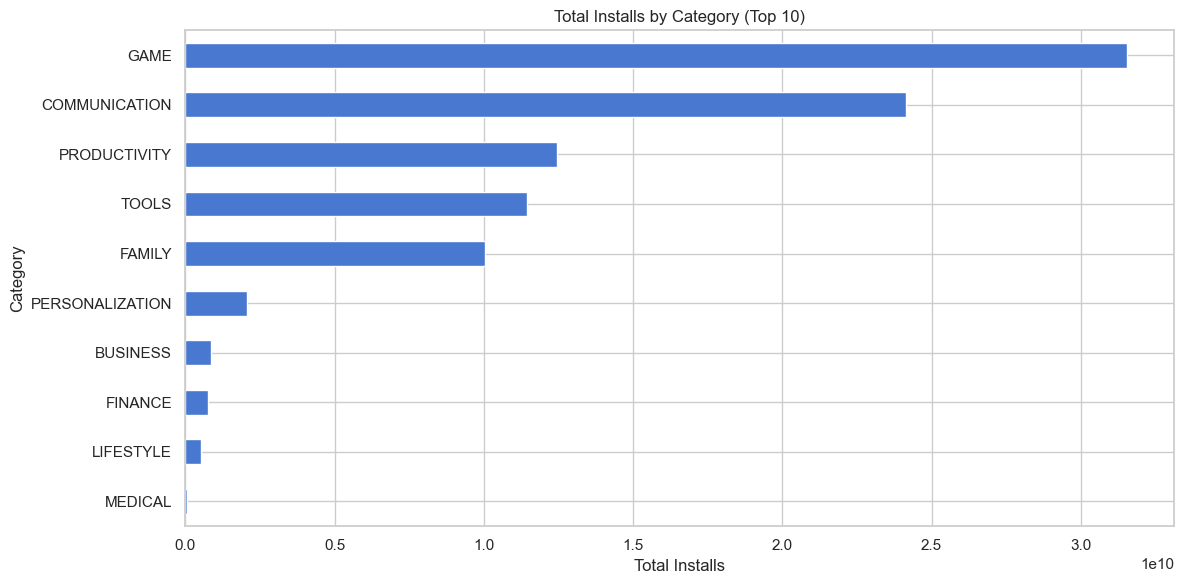

In [24]:
# Analysis using the cleaned data

# Category performance by app count and average rating
category_summary = (
    df_clean.groupby('Category')
    .agg(AppCount=('App', 'count'),
         AvgRating=('Rating', 'mean'),
         TotalInstalls=('Installs', 'sum'))
    .sort_values('AppCount', ascending=False)
)

print('Top 5 categories by number of apps:')
print(category_summary.head(5).to_string())

# Paid vs Free analysis
paid_summary = df_clean.groupby('Type').agg(AppCount=('App', 'count'),
                                             AvgRating=('Rating','mean'),
                                             TotalInstalls=('Installs','sum'))
print('\nPaid vs Free summary:')
print(paid_summary.to_string())

# Best performing paid apps by installs
print('\nTop 10 paid apps by installs:')
print(df_clean[df_clean['IsPaid']].sort_values('Installs', ascending=False).head(10)[['App','Category','Price','Installs','Rating']].to_string(index=False))

# Most installed categories
print('\nTop 5 categories by total installs:')
print(category_summary.sort_values('TotalInstalls', ascending=False).head(5).to_string())

# Visualize installs by category for the top 10 categories
if plotting_enabled:
    plt.figure(figsize=(12,6))
    category_summary.head(10).sort_values('TotalInstalls', ascending=True)['TotalInstalls'].plot(kind='barh')
    plt.title('Total Installs by Category (Top 10)')
    plt.xlabel('Total Installs')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()
else:
    print('Skipping installs by category chart because plotting libraries are unavailable.')

### Link to Published Dashboard
`https://public.tableau.com/views/YourDashboardName`

## Conclusion
- The dataset shows that `FAMILY`, `GAME`, and `TOOLS` are the largest categories by app count.
- Free apps dominate the store, with about 10,039 free apps versus 800 paid apps.
- Paid apps such as `Minecraft` and `Hitman Sniper` still achieve high installs, so premium app opportunities exist in select categories.
- Data preparation reveals important cleaning needs: numeric conversions for `Price`, `Installs`, `Reviews`, and `Size`, plus handling of missing `Rating` values.
- The cleaned file `google_play_store_dataset_cleaned.csv` is ready for dashboarding and further business analysis.